In [753]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.impute import SimpleImputer

In [3]:
data_train_category = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")

data_train_quantative = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")

data_train_funct_matrix = pd.read_csv("./widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

data_train_solution = pd.read_excel("./widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [4]:
data_test_category = pd.read_excel("./widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx")

data_test_quantative = pd.read_excel("./widsdatathon2025/TEST/TEST_QUANTITATIVE_METADATA.xlsx")

data_test_funct_matrix = pd.read_csv("./widsdatathon2025/TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

# Inspect Quantative data

In [212]:
final_data_train_quantative = pd.merge(data_train_quantative, data_train_solution, on='participant_id')

In [253]:
import pandas as pd
import numpy as np

# Calculate correlation matrix
corr_matrix = final_data_train_quantative.iloc[:, 1:-2].corr()

# Mask the lower triangle (keep upper triangle only)
mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
corr_matrix_upper = corr_matrix.mask(mask)

corr_matrix_upper

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
EHQ_EHQ_Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ColorVision_CV_Score,0.011680,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_CP,-0.040262,0.025139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_ID,-0.009224,-0.022344,0.243894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_INV,-0.013310,-0.029387,-0.112408,-0.212678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_OPD,-0.052585,-0.012615,0.294989,0.283776,-0.006013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_PM,0.030519,-0.030832,0.059381,0.206431,-0.210864,0.033536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQ_P_APQ_P_PP,-0.031832,0.000217,-0.031953,-0.110567,0.563462,0.119990,-0.132702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDQ_SDQ_Conduct_Problems,-0.048658,0.003944,0.218821,0.286364,-0.190359,0.349045,0.094364,-0.079546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDQ_SDQ_Difficulties_Total,-0.047746,0.002189,0.191669,0.259277,-0.198900,0.308266,0.028366,-0.060789,0.723020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [254]:
corr_matrix_upper['ColorVision_CV_Score'].dropna()

APQ_P_APQ_P_CP                0.025139
APQ_P_APQ_P_ID               -0.022344
APQ_P_APQ_P_INV              -0.029387
APQ_P_APQ_P_OPD              -0.012615
APQ_P_APQ_P_PM               -0.030832
APQ_P_APQ_P_PP                0.000217
SDQ_SDQ_Conduct_Problems      0.003944
SDQ_SDQ_Difficulties_Total    0.002189
SDQ_SDQ_Emotional_Problems    0.024828
SDQ_SDQ_Externalizing         0.002035
SDQ_SDQ_Generating_Impact     0.037464
SDQ_SDQ_Hyperactivity         0.000149
SDQ_SDQ_Internalizing         0.001670
SDQ_SDQ_Peer_Problems        -0.022902
SDQ_SDQ_Prosocial             0.030270
MRI_Track_Age_at_Scan        -0.032827
Name: ColorVision_CV_Score, dtype: float64

In [259]:
def correlation_between_features(data: pd.DataFrame, threshold: float = 0.5, need_high_corr_between_features: bool = True) -> list:
    """
    Calculate the correlation between features in a given DataFrame 
     
    Return a list of DataFrames whose correlation between features above (or below) a given threshold.

    Example: Our output have three columns in a DataFrame: A, B, C then output will consider the correlation between A and B, A and C, not B and C.

    Note: threshold will be high if need_high_corr is True, otherwise low threshold.

    Parameters:
    - data: pd.DataFrame - The input DataFrame containing features.
    - threshold: float - The correlation threshold to filter features.
    
    Returns:
    - List of DataFrame - A list of Dataframe containing the features with correlations above (or below) the threshold.
    """
    
    # Calculate correlation matrix
    corr_matrix = data.corr()

    # Mask the lower triangle (keep upper triangle only)
    mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
    
    corr_matrix = corr_matrix.mask(mask)

    list_of_dataframe = []
    for col in corr_matrix.columns:

        values_corr = corr_matrix[col]
        values_corr = values_corr.dropna()
        values_corr = np.abs(values_corr)

        low_corr = values_corr[values_corr < threshold]
        high_corr = values_corr[values_corr >= threshold]

        if need_high_corr_between_features:
            if len(high_corr) > 0:
                df = pd.DataFrame(data[[col] + list(high_corr.index)])
                list_of_dataframe.append(df)
        else:
            if len(low_corr) > 0:
                df = pd.DataFrame(data[[col] + list(low_corr.index)])
                list_of_dataframe.append(df)
    
    return list_of_dataframe
    

In [ ]:
correlation_between_features(final_data_train_quantative.iloc[:, 1:-2], threshold=0.2, need_high_corr_between_features=False)

In [215]:
# Get all rows that have more than 3 NaN values from its columns
rows_filtered = final_data_train_quantative[final_data_train_quantative.isnull().sum(axis = 1) > 3]

# Get final_data_train_quantative without the rows that have more than 3 NaN values from its columns
final_data_train_quantative_remove_NaN = final_data_train_quantative[final_data_train_quantative.isnull().sum(axis = 1) <= 3]


In [216]:
final_data_train_quantative_remove_NaN.isnull().sum(axis = 0)

participant_id                  0
EHQ_EHQ_Total                  12
ColorVision_CV_Score           21
APQ_P_APQ_P_CP                  0
APQ_P_APQ_P_ID                  0
APQ_P_APQ_P_INV                 0
APQ_P_APQ_P_OPD                 0
APQ_P_APQ_P_PM                  0
APQ_P_APQ_P_PP                  0
SDQ_SDQ_Conduct_Problems        0
SDQ_SDQ_Difficulties_Total      0
SDQ_SDQ_Emotional_Problems      0
SDQ_SDQ_Externalizing           0
SDQ_SDQ_Generating_Impact       0
SDQ_SDQ_Hyperactivity           0
SDQ_SDQ_Internalizing           0
SDQ_SDQ_Peer_Problems           0
SDQ_SDQ_Prosocial               0
MRI_Track_Age_at_Scan         355
ADHD_Outcome                    0
Sex_F                           0
dtype: int64

In [217]:
correlate_between_features = correlation_between_features(final_data_train_quantative_remove_NaN.iloc[:, 1:-2], threshold=0.8)
for i in correlate_between_features:
    print(i.isnull().sum())
    print("========================================")
    print()

correlate_between_features[0][correlate_between_features[0].isnull().all(axis = 1)]

EHQ_EHQ_Total    12
dtype: int64

ColorVision_CV_Score    21
dtype: int64

APQ_P_APQ_P_CP    0
dtype: int64

APQ_P_APQ_P_ID    0
dtype: int64

APQ_P_APQ_P_INV    0
dtype: int64

APQ_P_APQ_P_OPD    0
dtype: int64

APQ_P_APQ_P_PM    0
dtype: int64

APQ_P_APQ_P_PP    0
dtype: int64

SDQ_SDQ_Conduct_Problems    0
dtype: int64

SDQ_SDQ_Difficulties_Total    0
SDQ_SDQ_Externalizing         0
SDQ_SDQ_Internalizing         0
dtype: int64

SDQ_SDQ_Emotional_Problems    0
SDQ_SDQ_Internalizing         0
dtype: int64

SDQ_SDQ_Externalizing         0
SDQ_SDQ_Difficulties_Total    0
SDQ_SDQ_Hyperactivity         0
dtype: int64

SDQ_SDQ_Generating_Impact    0
dtype: int64

SDQ_SDQ_Hyperactivity    0
SDQ_SDQ_Externalizing    0
dtype: int64

SDQ_SDQ_Internalizing         0
SDQ_SDQ_Difficulties_Total    0
SDQ_SDQ_Emotional_Problems    0
SDQ_SDQ_Peer_Problems         0
dtype: int64

SDQ_SDQ_Peer_Problems    0
SDQ_SDQ_Internalizing    0
dtype: int64

SDQ_SDQ_Prosocial    0
dtype: int64

MRI_Track_Age_at_

,EHQ_EHQ_Total
80,NaN
84,NaN
212,NaN
286,NaN
325,NaN
465,NaN
472,NaN
857,NaN
870,NaN
1022,NaN


We should remove MRI_Track_Age_At_Scan since it has so much null values -> very difficult to fill na

# Fill_in

In [ ]:
# Lấy subset data
data = final_data_train_quantative.iloc[:, 1:-2]

# Duyệt từng cột
for col in data.columns:
    # Tính correlation của col với các cột còn lại
    corr_values = data.corrwith(data[col]).abs()
    
    # Xóa self-correlation
    corr_values = corr_values.drop(labels=[col])
    
    # Lọc ra các cột có correlation >= 0.7
    high_corr_cols = corr_values[corr_values >= 0.7].index.tolist()
    
    # In ra
    if high_corr_cols:
        print(f"Các cột có correlation >= 0.8 với {col}: {high_corr_cols}")
        for ref_col in high_corr_cols:
            # Lấy dữ liệu
            relative_data = final_data_train_quantative[[col, ref_col]]
            # Chia bin: ví dụ chia 4 bins dựa trên ref_col1 (quartiles)
            relative_data['bin'] = pd.qcut(relative_data[ref_col], q=4, labels=False)
            print(relative_data[['bin', col]])
            # Tính mean của col dựa trên bin
            mean_values = relative_data.groupby('bin')[col].mean()


## Feature engineering

In [218]:
# Drop MRI columns
final_data_train_quantative_remove_NaN = final_data_train_quantative_remove_NaN.drop(columns=['MRI_Track_Age_at_Scan']).copy()

### Fill median for features that have missing value

Note: Fill median now leads to data leakage so this is used only for feature engineering purpose

In [248]:
imputer = SimpleImputer(strategy='median')

final_data_train_quantative_fill_NaN = imputer.fit_transform(final_data_train_quantative_remove_NaN.iloc[:, 1: -2])
final_data_train_quantative_fill_NaN = pd.DataFrame(final_data_train_quantative_fill_NaN, columns=final_data_train_quantative_remove_NaN.columns[1: -2])
final_data_train_quantative_fill_NaN.isnull().sum()

EHQ_EHQ_Total                 0
ColorVision_CV_Score          0
APQ_P_APQ_P_CP                0
APQ_P_APQ_P_ID                0
APQ_P_APQ_P_INV               0
APQ_P_APQ_P_OPD               0
APQ_P_APQ_P_PM                0
APQ_P_APQ_P_PP                0
SDQ_SDQ_Conduct_Problems      0
SDQ_SDQ_Difficulties_Total    0
SDQ_SDQ_Emotional_Problems    0
SDQ_SDQ_Externalizing         0
SDQ_SDQ_Generating_Impact     0
SDQ_SDQ_Hyperactivity         0
SDQ_SDQ_Internalizing         0
SDQ_SDQ_Peer_Problems         0
SDQ_SDQ_Prosocial             0
dtype: int64

In [260]:
from sklearn.feature_selection import SelectKBest, f_classif
def correlation_between_features(data: pd.DataFrame, threshold: float = 0.5, need_high_corr_between_features: bool = True) -> list:
    """
    Calculate the correlation between features in a given DataFrame 
     
    Return a list of DataFrames whose correlation between features above (or below) a given threshold.

    Example: Our output have three columns in a DataFrame: A, B, C then output will consider the correlation between A and B, A and C, not B and C.

    Note: threshold will be high if need_high_corr is True, otherwise low threshold.

    Parameters:
    - data: pd.DataFrame - The input DataFrame containing features.
    - threshold: float - The correlation threshold to filter features.
    
    Returns:
    - List of DataFrame - A list of Dataframe containing the features with correlations above (or below) the threshold.
    """
    
    # Calculate correlation matrix
    corr_matrix = data.corr()

    # Mask the lower triangle (keep upper triangle only)
    mask = np.triu(np.ones(corr_matrix.shape)).astype(bool)
    
    corr_matrix = corr_matrix.mask(mask)

    list_of_dataframe = []
    for col in corr_matrix.columns:

        values_corr = corr_matrix[col]
        values_corr = values_corr.dropna()
        values_corr = np.abs(values_corr)

        low_corr = values_corr[values_corr < threshold]
        high_corr = values_corr[values_corr >= threshold]

        if need_high_corr_between_features:
            if len(high_corr) > 0:
                df = pd.DataFrame(data[[col] + list(high_corr.index)])
                list_of_dataframe.append(df)
        else:
            if len(low_corr) > 0:
                df = pd.DataFrame(data[[col] + list(low_corr.index)])
                list_of_dataframe.append(df)
    
    return list_of_dataframe
    

def Anova_test_for_multiple_features(features: pd.DataFrame, target: pd.Series, alpha: float = 0.025) -> pd.DataFrame:
    """
    Perform ANOVA test for multiple features against a target variable.

    ANOVA test is used to determine if the means of a feature are significantly different between classes.

    This is used for feature selection

    Null hypothesis: The means of the feature are equal across all classes.

    Alternative hypothesis: At least the means of the feature coming frome one class is different.
    """
    results = []
    
    len_features = len(features.columns)

    selector = SelectKBest(f_classif, k = len_features)
    selector.fit(features, target)

    final = pd.DataFrame(data = {'F-score': selector.scores_, 'p-value': selector.pvalues_}, index = features.columns)

    for p_value in final['p-value']:
        if p_value <= alpha:
            results.append('Reject null hypothesis')
        else:
            results.append('Fail to reject null hypothesis')
    
    final['result'] = results
    
    return final
    

In [234]:
result = pd.concat([final_data_train_quantative_remove_NaN['Sex_F'], final_data_train_quantative_remove_NaN['ADHD_Outcome'].sort_values(ascending = True)], axis=1, join='inner')
result

,Sex_F,ADHD_Outcome
0,0,1
1,0,1
2,1,0
3,1,0
4,0,1
...,...,...
1208,1,0
1209,0,1
1210,1,1
1211,0,1


In [282]:
final_data_train_quantative_fill_NaN[['SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Prosocial', 'SDQ_SDQ_Externalizing']].corr()

,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Prosocial,SDQ_SDQ_Externalizing
SDQ_SDQ_Hyperactivity,1.000000,0.320867,-0.326545,0.899023
SDQ_SDQ_Emotional_Problems,0.320867,1.000000,-0.126529,0.376726
SDQ_SDQ_Prosocial,-0.326545,-0.126529,1.000000,-0.442046
SDQ_SDQ_Externalizing,0.899023,0.376726,-0.442046,1.000000


In [284]:
a = correlation_between_features(final_data_train_quantative_fill_NaN, 0.8, True)
y = final_data_train_quantative_remove_NaN['Sex_F']
feature_collect = []
for dataframe in a:
    columns = dataframe.columns
    first_col = dataframe[[columns[0]]]
    
    other_cols = dataframe[columns[1:]]
    # Perform ANOVA test

    anova_results_for_other_cols = Anova_test_for_multiple_features(other_cols, y, alpha = 0.025)                                  
    
    filtered_other_cols = anova_results_for_other_cols[anova_results_for_other_cols['result'] == 'Reject null hypothesis'].index.tolist()

    anova_results_for_first_col = Anova_test_for_multiple_features(first_col, y, alpha = 0.025)

    filtered_first_col = anova_results_for_first_col[anova_results_for_first_col['result'] == 'Reject null hypothesis'].index.tolist()

    best_features = None

    if len(filtered_first_col) > 0:
        if len(filtered_other_cols) > 0:
            columns = filtered_first_col + filtered_other_cols
            final_anova_results = Anova_test_for_multiple_features(dataframe[columns], y, alpha = 0.025)

            best_features = final_anova_results[final_anova_results['p-value'] == final_anova_results['p-value'].min()].index.tolist()[0]
        
        else:
            best_features = filtered_first_col[0]
        
    else:
        if len(filtered_other_cols) > 0:
            columns = filtered_other_cols
            final_anova_results = Anova_test_for_multiple_features(dataframe[columns], y, alpha = 0.025) 

            best_features = final_anova_results[final_anova_results['p-value'] == final_anova_results['p-value'].min()].index.tolist()[0]
        else:
            best_features = None
    
    if best_features is not None:
        feature_collect.append(best_features)

   
feature_collect
correlation_between_features(final_data_train_quantative_fill_NaN[feature_collect], 0.8, True)
    
        

[      SDQ_SDQ_Externalizing  SDQ_SDQ_Hyperactivity
 0                      11.0                    8.0
 1                      13.0                    8.0
 2                      10.0                    7.0
 3                       3.0                    3.0
 4                      15.0                    9.0
 ...                     ...                    ...
 1187                   13.0                    8.0
 1188                    5.0                    3.0
 1189                    9.0                    7.0
 1190                    8.0                    7.0
 1191                    9.0                    7.0
 
 [1192 rows x 2 columns]]

In [291]:
a = correlation_between_features(final_data_train_quantative_fill_NaN, 0.2, False)
y = final_data_train_quantative_remove_NaN['Sex_F']
feature_collect = []
first_col_collect = []

for dataframe in a:
    columns = dataframe.columns

    first_col = dataframe[[columns[0]]]
    first_col_collect.append(columns[0])

first_col_collect = list(set(first_col_collect))

first_col_collect
Anova_test_for_multiple_features(final_data_train_quantative_fill_NaN[first_col_collect], y, alpha = 0.025)

,F-score,p-value,result
APQ_P_APQ_P_INV,5.299740,0.021501,Reject null hypothesis
APQ_P_APQ_P_PM,0.009953,0.920546,Fail to reject null hypothesis
APQ_P_APQ_P_CP,1.587972,0.207863,Fail to reject null hypothesis
ColorVision_CV_Score,13.441320,0.000257,Reject null hypothesis
APQ_P_APQ_P_PP,5.877165,0.015487,Reject null hypothesis
APQ_P_APQ_P_ID,0.339794,0.560058,Fail to reject null hypothesis
SDQ_SDQ_Emotional_Problems,13.071563,0.000312,Reject null hypothesis
EHQ_EHQ_Total,0.028599,0.865738,Fail to reject null hypothesis
APQ_P_APQ_P_OPD,4.192997,0.040810,Fail to reject null hypothesis


features after anova : APQ_P_APQ_P_INV, ColorVision_CV_Score, APQ_P_APQ_P_PP, SDQ_SDQ_Emotional_Problems

In [ ]:
from scipy.stats import ks_2samp
def Kolmogorov_Smirnov_Test(df_train: pd.DataFrame, df_test: pd.DataFrame) -> pd.DataFrame:
    """
    Perform Kolmogorov-Smirnov test between two dataframes.

    Null hypothesis: The two samples are drawn from the same distribution.

    Alternative hypothesis: The two samples are drawn from different distributions.
    """
    ks_results = {}
    df_train = df_train.copy()
    df_test = df_test.copy()

    columns_df_train = df_train
    columns_df_test = df_test

    for col in columns_df_train:
        data_train = df_train[col]
        data_test = df_test[col]

        # Perform the Kolmogorov-Smirnov test
        ks_statistic, p_value = ks_2samp(data_train, data_test)
        result = None
        if p_value < 0.025:
            result = "Reject null hypothesis"
        else:
            result = "Fail to reject null hypothesis"
            

        # Store the results
        ks_results[col] = {
            'KS Statistic': ks_statistic,
            'p-value': p_value,
            'result': result
        }
    
    # Convert the results to a DataFrame for better visualization
    ks_results_df = pd.DataFrame(ks_results).T
    return ks_results_df

In [295]:
data_test_quantative

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,Cfwaf5FX7jWK,60.03,14.0,5.0,16.0,41.0,19.0,11.0,26.0,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,vhGrzmvA3Hjq,86.71,12.0,3.0,13.0,43.0,18.0,15.0,28.0,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,ULliyEXjy4OV,26.68,13.0,3.0,14.0,36.0,16.0,14.0,25.0,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,LZfeAb1xMtql,93.38,13.0,3.0,19.0,41.0,17.0,18.0,27.0,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,EnFOUv0YK1RG,-93.38,14.0,3.0,13.0,42.0,19.0,16.0,28.0,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,UadZfjdEg7eG,86.71,14.0,3.0,17.0,41.0,17.0,11.0,25.0,1.0,18.0,7.0,7.0,5.0,6.0,11.0,4.0,7.0,7.546999
300,IUEHiLmQAqCi,73.37,14.0,5.0,12.0,38.0,22.0,9.0,29.0,2.0,16.0,2.0,11.0,5.0,9.0,5.0,3.0,8.0,10.531143
301,cRySmCadYFRO,87.84,13.0,3.0,14.0,42.0,15.0,10.0,28.0,1.0,11.0,4.0,4.0,4.0,3.0,7.0,3.0,10.0,7.210586
302,E3MvDUtJadc5,46.76,14.0,3.0,16.0,43.0,18.0,12.0,22.0,5.0,21.0,2.0,10.0,6.0,5.0,11.0,9.0,0.0,12.212183


In [294]:
final_data_train_quantative_fill_NaN[['APQ_P_APQ_P_INV', 'ColorVision_CV_Score', 'APQ_P_APQ_P_PP', 'SDQ_SDQ_Emotional_Problems']]

,APQ_P_APQ_P_INV,ColorVision_CV_Score,APQ_P_APQ_P_PP,SDQ_SDQ_Emotional_Problems
0,44.0,13.0,27.0,4.0
1,35.0,14.0,30.0,4.0
2,37.0,14.0,28.0,7.0
3,42.0,14.0,28.0,0.0
4,35.0,14.0,24.0,7.0
...,...,...,...,...
1187,36.0,14.0,22.0,5.0
1188,42.0,14.0,25.0,0.0
1189,34.0,14.0,25.0,3.0
1190,45.0,14.0,30.0,0.0


,KS Statistic,p-value,result
APQ_P_APQ_P_INV,NaN,NaN,Fail to reject null hypothesis
ColorVision_CV_Score,NaN,NaN,Fail to reject null hypothesis
APQ_P_APQ_P_PP,NaN,NaN,Fail to reject null hypothesis
SDQ_SDQ_Emotional_Problems,NaN,NaN,Fail to reject null hypothesis


In [300]:
final_data_train_quantative_fill_NaN['APQ_P_APQ_P_INV']

0       44.0
1       35.0
2       37.0
3       42.0
4       35.0
        ... 
1187    36.0
1188    42.0
1189    34.0
1190    45.0
1191    45.0
Name: APQ_P_APQ_P_INV, Length: 1192, dtype: float64

In [305]:
data_test_quantative.isnull().sum(axis = 1).value_counts()

0     259
9      20
15     10
1      10
6       5
Name: count, dtype: int64

In [313]:
data_test_quantative_remove_na = data_test_quantative[data_test_quantative.isnull().sum(axis = 1) <=3]
data_test_quantative_remove_na.isnull().sum(axis = 0)
imputer = SimpleImputer(strategy='median')
data_test_quantative_fill_na = imputer.fit_transform(data_test_quantative_remove_na.iloc[:, 1:])
data_test_quantative_fill_na = pd.DataFrame(data_test_quantative_fill_na, columns=data_test_quantative_remove_na.columns[1:])
data_test_quantative_fill_na.head()

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,60.03,14.0,5.0,16.0,41.0,19.0,11.0,26.0,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,86.71,12.0,3.0,13.0,43.0,18.0,15.0,28.0,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,26.68,13.0,3.0,14.0,36.0,16.0,14.0,25.0,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,93.38,13.0,3.0,19.0,41.0,17.0,18.0,27.0,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,-93.38,14.0,3.0,13.0,42.0,19.0,16.0,28.0,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350


In [334]:
Kolmogorov_Smirnov_Test(final_data_train_quantative_fill_NaN[first_col_collect], 
                        data_test_quantative_fill_na[first_col_collect])

,KS Statistic,p-value,result
APQ_P_APQ_P_INV,0.03352,0.95781,Fail to reject null hypothesis
APQ_P_APQ_P_PM,0.079748,0.11523,Fail to reject null hypothesis
APQ_P_APQ_P_CP,0.209869,0.0,Reject null hypothesis
ColorVision_CV_Score,0.145091,0.000169,Reject null hypothesis
APQ_P_APQ_P_PP,0.117138,0.004384,Reject null hypothesis
APQ_P_APQ_P_ID,0.030501,0.982337,Fail to reject null hypothesis
SDQ_SDQ_Emotional_Problems,0.032955,0.96346,Fail to reject null hypothesis
EHQ_EHQ_Total,0.148699,0.000105,Reject null hypothesis
APQ_P_APQ_P_OPD,0.163525,0.000013,Reject null hypothesis


features after ks test : APQ_P_APQ_P_INV, SDQ_SDQ_Emotional_Problems

# Inspect connectome matrix data

In [289]:
data_train_funct_matrix

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
1,WHWymJu6zNZi,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
2,4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
3,obEacy4Of68I,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
4,s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,9gpepMI9sj5q,0.265284,0.551726,0.628318,0.647700,0.710757,0.132334,0.326207,0.354319,0.531170,...,0.127097,0.129787,0.298987,0.114577,0.534109,0.118893,0.181292,0.181055,0.238357,0.577009
1209,FIDen5rdMc0v,-0.018377,0.576689,0.527451,0.327463,0.586868,0.573689,0.300544,0.301103,0.659840,...,0.482214,-0.159587,-0.162498,-0.093249,0.309914,0.143818,0.218337,0.389331,0.328741,0.238443
1210,dlsMC4TXL4e8,0.227028,0.405659,0.023545,-0.093085,-0.068960,0.647574,0.762552,0.465109,0.199337,...,-0.379304,0.126976,0.193695,0.214483,0.429836,0.302141,0.104774,0.856375,0.303248,0.363639
1211,syeyZjEx8FUx,0.189849,0.752876,0.842463,0.817037,0.820196,0.792950,0.650929,0.488504,0.580207,...,-0.212254,-0.055539,-0.221935,-0.202464,0.602651,0.482066,0.399363,0.373746,0.279900,0.684434


In [321]:
data_test_funct_matrix.iloc[:, 1:]

,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,0.548480,0.713607,0.557319,0.524369,0.693364,0.770032,0.724406,0.390118,0.547912,0.470220,...,0.080423,-0.054581,-0.088163,-0.028574,0.444847,0.350149,-0.012601,0.665750,0.560565,0.555732
1,0.427740,0.363022,0.402862,0.363003,0.534558,0.345347,0.409471,0.303328,0.402515,0.275052,...,0.198009,-0.000724,0.083122,0.033043,0.687497,0.306229,0.717485,0.461809,0.559632,0.350027
2,0.139572,0.390106,-0.087041,0.196852,0.088148,0.023843,0.381782,0.068979,0.377488,0.301871,...,0.051319,0.023630,-0.056819,0.117396,0.576086,0.517831,0.527044,0.605038,0.609856,0.750987
3,0.133561,0.778326,0.416355,0.471840,0.568460,0.633660,0.501113,0.345461,0.467943,0.417308,...,0.046183,-0.238962,0.121868,-0.260970,0.646818,0.594902,0.608156,0.595459,0.683189,0.542296
4,0.126699,0.575446,0.509422,0.363193,0.427544,0.449924,0.451796,0.223927,0.298248,0.304429,...,0.315734,0.002234,0.290791,0.344149,0.480214,0.539824,0.447322,0.293088,0.148529,0.539823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,0.029721,0.596742,0.361898,0.292066,0.553130,0.476284,0.543970,0.372932,0.595183,0.265432,...,0.021524,-0.162832,0.105546,0.028975,0.576180,0.378365,0.399277,0.556115,0.490833,0.568742
300,0.025985,0.347840,0.304804,0.463090,0.305321,0.267397,0.468712,0.155677,0.298155,0.049262,...,0.044974,-0.078047,-0.118271,0.035741,0.640073,0.515096,0.206462,0.536001,0.318518,0.305596
301,0.105385,0.443624,-0.019777,0.435582,0.376492,0.619322,0.430177,0.567600,0.399820,0.371101,...,0.145582,0.004455,0.134574,-0.152951,0.782938,0.737555,0.593972,0.734463,0.680979,0.678973
302,0.345641,0.758986,0.748153,0.442141,0.571924,0.485011,0.530513,0.137672,0.467144,0.172004,...,0.036169,-0.345563,-0.165280,-0.347035,0.657024,0.590523,0.094565,0.727339,0.429694,0.530238


In [322]:
data_train_funct_matrix.iloc[:, 1:]


,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,0.470063,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
1,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,0.276350,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
2,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,0.378557,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
3,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,0.259596,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
4,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,0.331445,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,0.265284,0.551726,0.628318,0.647700,0.710757,0.132334,0.326207,0.354319,0.531170,0.340388,...,0.127097,0.129787,0.298987,0.114577,0.534109,0.118893,0.181292,0.181055,0.238357,0.577009
1209,-0.018377,0.576689,0.527451,0.327463,0.586868,0.573689,0.300544,0.301103,0.659840,0.434427,...,0.482214,-0.159587,-0.162498,-0.093249,0.309914,0.143818,0.218337,0.389331,0.328741,0.238443
1210,0.227028,0.405659,0.023545,-0.093085,-0.068960,0.647574,0.762552,0.465109,0.199337,-0.357953,...,-0.379304,0.126976,0.193695,0.214483,0.429836,0.302141,0.104774,0.856375,0.303248,0.363639
1211,0.189849,0.752876,0.842463,0.817037,0.820196,0.792950,0.650929,0.488504,0.580207,0.162963,...,-0.212254,-0.055539,-0.221935,-0.202464,0.602651,0.482066,0.399363,0.373746,0.279900,0.684434


In [325]:
data = Kolmogorov_Smirnov_Test(data_train_funct_matrix.iloc[:, 1:], data_test_funct_matrix.iloc[:, 1:])
features_connectome = data[data['result'] == 'Fail to reject null hypothesis'].index.tolist()

In [330]:
data_train_funct_matrix_after_ks = data_train_funct_matrix[['participant_id'] + features_connectome]
data_train_funct_matrix_after_ks = pd.merge(data_train_funct_matrix_after_ks, data_train_solution, on='participant_id')
data_train_funct_matrix_after_ks

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,0throw_10thcolumn,0throw_12thcolumn,0throw_13thcolumn,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.508408,-0.078290,0.525692,0.470063,0.061988,-0.004754,...,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221,1,0
1,WHWymJu6zNZi,0.614765,0.577255,0.496127,0.122590,-0.085452,0.120673,0.276350,-0.355816,-0.378783,...,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176,1,1
2,4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.637110,0.192010,0.520379,0.378557,-0.192733,-0.183192,...,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232,1,1
3,obEacy4Of68I,0.199688,0.752714,0.658283,0.522750,0.412188,0.530843,0.259596,-0.154625,0.130466,...,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193,1,1
4,s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.266676,0.359668,0.300771,0.331445,-0.108351,0.014970,...,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,9gpepMI9sj5q,0.265284,0.551726,0.628318,0.326207,0.354319,0.531170,0.340388,0.155009,-0.290833,...,0.298987,0.114577,0.534109,0.118893,0.181292,0.181055,0.238357,0.577009,0,1
1209,FIDen5rdMc0v,-0.018377,0.576689,0.527451,0.300544,0.301103,0.659840,0.434427,-0.111788,-0.073784,...,-0.162498,-0.093249,0.309914,0.143818,0.218337,0.389331,0.328741,0.238443,1,0
1210,dlsMC4TXL4e8,0.227028,0.405659,0.023545,0.762552,0.465109,0.199337,-0.357953,-0.130444,0.121617,...,0.193695,0.214483,0.429836,0.302141,0.104774,0.856375,0.303248,0.363639,1,0
1211,syeyZjEx8FUx,0.189849,0.752876,0.842463,0.650929,0.488504,0.580207,0.162963,-0.110064,-0.246551,...,-0.221935,-0.202464,0.602651,0.482066,0.399363,0.373746,0.279900,0.684434,0,1


In [776]:
anova_result_connectome = Anova_test_for_multiple_features(data_train_funct_matrix_after_ks.iloc[:, 1:-2], data_train_funct_matrix_after_ks['Sex_F'], alpha = 0.01)
anova_result_connectome_filter = anova_result_connectome[anova_result_connectome['result'] == 'Reject null hypothesis'].index.tolist()
anova_result_connectome_filter

['0throw_75thcolumn',
 '0throw_81thcolumn',
 '0throw_84thcolumn',
 '0throw_85thcolumn',
 '0throw_87thcolumn',
 '0throw_98thcolumn',
 '0throw_107thcolumn',
 '0throw_123thcolumn',
 '0throw_130thcolumn',
 '0throw_140thcolumn',
 '0throw_163thcolumn',
 '0throw_186thcolumn',
 '0throw_187thcolumn',
 '0throw_195thcolumn',
 '1throw_30thcolumn',
 '1throw_45thcolumn',
 '1throw_131thcolumn',
 '3throw_27thcolumn',
 '3throw_62thcolumn',
 '4throw_27thcolumn',
 '4throw_38thcolumn',
 '4throw_62thcolumn',
 '4throw_132thcolumn',
 '4throw_141thcolumn',
 '4throw_150thcolumn',
 '4throw_168thcolumn',
 '5throw_27thcolumn',
 '5throw_38thcolumn',
 '5throw_132thcolumn',
 '6throw_24thcolumn',
 '6throw_40thcolumn',
 '6throw_43thcolumn',
 '6throw_75thcolumn',
 '6throw_77thcolumn',
 '6throw_100thcolumn',
 '6throw_132thcolumn',
 '6throw_144thcolumn',
 '6throw_148thcolumn',
 '7throw_27thcolumn',
 '7throw_178thcolumn',
 '7throw_189thcolumn',
 '8throw_14thcolumn',
 '8throw_77thcolumn',
 '8throw_132thcolumn',
 '8throw_14

In [777]:
feature_complete = ['APQ_P_APQ_P_INV', 'SDQ_SDQ_Emotional_Problems'] + anova_result_connectome_filter
len(feature_complete)

986

# Time to test

In [778]:
final_data_cat = pd.merge(data_train_category, data_train_quantative, on = 'participant_id')
final_data_mat = pd.merge(final_data_cat, data_train_funct_matrix, on = 'participant_id')
final_data_train = pd.merge(final_data_mat, data_train_solution, on = 'participant_id')
final_data_train

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,...,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,...,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182,0,1
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,...,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613,0,1
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,...,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zwjJWCRzKhDz,2019,4,1.0,1.0,3.0,12.0,NaN,15.0,5.0,...,0.112789,0.211312,0.601190,0.587116,0.312695,0.485938,0.189102,0.354333,0,1
1209,zwXD5v17Rx01,2018,1,0.0,0.0,3.0,21.0,40.0,21.0,40.0,...,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121,1,0
1210,zWzLCi3NTBTd,2018,3,2.0,3.0,3.0,21.0,40.0,21.0,35.0,...,0.044653,0.234887,0.538475,0.024265,0.472322,0.095624,0.205326,0.182633,1,1
1211,Zy9GTHDxUbXU,2019,4,0.0,1.0,3.0,18.0,35.0,18.0,45.0,...,-0.035955,-0.062152,0.706214,0.183288,0.104987,0.420463,0.152727,0.706737,1,0


In [779]:
final_data_cat = pd.merge(data_test_category, data_test_quantative, on = 'participant_id')
final_data_test = pd.merge(final_data_cat, data_test_funct_matrix, on = 'participant_id')
final_data_test

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,Cfwaf5FX7jWK,2022,4,0.0,0.0,4,21.0,30.0,18.0,30.0,...,0.080423,-0.054581,-0.088163,-0.028574,0.444847,0.350149,-0.012601,0.665750,0.560565,0.555732
1,vhGrzmvA3Hjq,2023,4,0.0,0.0,4,21.0,45.0,NaN,30.0,...,0.198009,-0.000724,0.083122,0.033043,0.687497,0.306229,0.717485,0.461809,0.559632,0.350027
2,ULliyEXjy4OV,2022,4,0.0,0.0,4,21.0,40.0,18.0,40.0,...,0.051319,0.023630,-0.056819,0.117396,0.576086,0.517831,0.527044,0.605038,0.609856,0.750987
3,LZfeAb1xMtql,2022,4,0.0,0.0,3,21.0,45.0,21.0,45.0,...,0.046183,-0.238962,0.121868,-0.260970,0.646818,0.594902,0.608156,0.595459,0.683189,0.542296
4,EnFOUv0YK1RG,2022,4,2.0,0.0,4,18.0,0.0,21.0,45.0,...,0.315734,0.002234,0.290791,0.344149,0.480214,0.539824,0.447322,0.293088,0.148529,0.539823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,UadZfjdEg7eG,2023,4,0.0,0.0,4,18.0,0.0,18.0,35.0,...,0.021524,-0.162832,0.105546,0.028975,0.576180,0.378365,0.399277,0.556115,0.490833,0.568742
300,IUEHiLmQAqCi,2023,4,0.0,1.0,3,18.0,35.0,21.0,40.0,...,0.044974,-0.078047,-0.118271,0.035741,0.640073,0.515096,0.206462,0.536001,0.318518,0.305596
301,cRySmCadYFRO,2023,4,0.0,8.0,4,21.0,25.0,15.0,NaN,...,0.145582,0.004455,0.134574,-0.152951,0.782938,0.737555,0.593972,0.734463,0.680979,0.678973
302,E3MvDUtJadc5,2022,4,0.0,8.0,4,21.0,0.0,21.0,45.0,...,0.036169,-0.345563,-0.165280,-0.347035,0.657024,0.590523,0.094565,0.727339,0.429694,0.530238


In [780]:
final_data_train_sex = final_data_train[feature_complete + ['Sex_F']]
final_data_test_sex = final_data_test[feature_complete]

In [798]:
final_data_train_sex.to_csv('data_train_filtered_for_sex.csv', index = False)
final_data_test_sex.to_csv('data_test_filtered_for_sex.csv', index = False)

In [781]:
feature_complete

['APQ_P_APQ_P_INV',
 'SDQ_SDQ_Emotional_Problems',
 '0throw_75thcolumn',
 '0throw_81thcolumn',
 '0throw_84thcolumn',
 '0throw_85thcolumn',
 '0throw_87thcolumn',
 '0throw_98thcolumn',
 '0throw_107thcolumn',
 '0throw_123thcolumn',
 '0throw_130thcolumn',
 '0throw_140thcolumn',
 '0throw_163thcolumn',
 '0throw_186thcolumn',
 '0throw_187thcolumn',
 '0throw_195thcolumn',
 '1throw_30thcolumn',
 '1throw_45thcolumn',
 '1throw_131thcolumn',
 '3throw_27thcolumn',
 '3throw_62thcolumn',
 '4throw_27thcolumn',
 '4throw_38thcolumn',
 '4throw_62thcolumn',
 '4throw_132thcolumn',
 '4throw_141thcolumn',
 '4throw_150thcolumn',
 '4throw_168thcolumn',
 '5throw_27thcolumn',
 '5throw_38thcolumn',
 '5throw_132thcolumn',
 '6throw_24thcolumn',
 '6throw_40thcolumn',
 '6throw_43thcolumn',
 '6throw_75thcolumn',
 '6throw_77thcolumn',
 '6throw_100thcolumn',
 '6throw_132thcolumn',
 '6throw_144thcolumn',
 '6throw_148thcolumn',
 '7throw_27thcolumn',
 '7throw_178thcolumn',
 '7throw_189thcolumn',
 '8throw_14thcolumn',
 '8th

### Split data

In [811]:
X_train_sex, X_val_sex, y_train_sex, y_val_sex = train_test_split(final_data_train_sex.iloc[:, :-1], final_data_train_sex['Sex_F'], test_size=0.2, random_state=42, stratify=final_data_train_sex['Sex_F'])

In [812]:
submission_val = pd.read_csv('Submission_val.csv')
submission_val['Sex_F'] = y_val_sex.reset_index()['Sex_F']
submission_val.to_csv('Submission_val.csv', index=False)

In [813]:
imputer = SimpleImputer(strategy='median')
X_train_sex = imputer.fit_transform(X_train_sex)
X_val_sex = imputer.transform(X_val_sex)
X_test_sex = imputer.transform(final_data_test_sex)

In [814]:
scaler = StandardScaler()
X_train_sex = scaler.fit_transform(X_train_sex)
X_val_sex = scaler.transform(X_val_sex)
X_test_sex = scaler.transform(X_test_sex)

In [815]:
from sklearn.decomposition import PCA

pca = PCA(n_components=200)
X_train_sex = pca.fit_transform(X_train_sex)
X_val_sex = pca.transform(X_val_sex)
X_test_sex = pca.transform(X_test_sex)

In [732]:
X_test_sex.shape

(304, 200)

## Neura Network for Sex_F

In [816]:
X_test_sex_tensor = torch.tensor(X_test_sex, dtype=torch.float32)
X_train_sex_tensor = torch.tensor(X_train_sex, dtype=torch.float32)
X_val_sex_tensor = torch.tensor(X_val_sex, dtype=torch.float32)

y_train_sex_tensor = torch.tensor(y_train_sex.values, dtype=torch.float32)
y_val_sex_tensor = torch.tensor(y_val_sex.values, dtype=torch.float32)

In [788]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, index):
        
        return (self.X[index], self.y[index])


dataset_train_sex = CustomDataset(X_train_sex_tensor, y_train_sex_tensor)
dataset_val_sex = CustomDataset(X_val_sex_tensor, y_val_sex_tensor)

#dataset_test_sex = CustomDataset(X_test, y_test)
    

In [789]:
Batch_Size = 64
dataloader_train = DataLoader(dataset_train_sex, batch_size=Batch_Size, shuffle=True)
dataloader_val = DataLoader(dataset_val_sex, batch_size=Batch_Size, shuffle=False)
#dataloader_test = DataLoader(dataset_test, batch_size=Batch_Size, shuffle=False)

In [842]:
from typing import Literal, Optional
import math
import random
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, output_size,):
        super().__init__()
        
        # Set up layers
        layers = [
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.Tanh(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 125),
            nn.BatchNorm1d(125),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            
            nn.Linear(125, 256),
            nn.BatchNorm1d(256),
            nn.Softplus(),
            
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.PReLU(),
            
            nn.Linear(64, output_size),  # If it's regression, output_size=1
        ]
        
        self.classifier = nn.Sequential(*layers)
        
        # # Initialize weights
        # for layer in self.classifier:
        #     if isinstance(layer, nn.Linear):
        #         nn.init.xavier_uniform_(layer.weight)
        #         if layer.bias is not None:
        #             nn.init.zeros_(layer.bias)

        # # Initialize weights
        # for layer in self.classifier:
        #     if isinstance(layer, nn.Linear):
        #         nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')  # or 'leaky_relu'
        #         if layer.bias is not None:
        #             nn.init.zeros_(layer.bias)
    
    def forward(self, X):
        output = self.classifier(X)
        return output

In [737]:
def accuracy_for_multiple_target_variable(df_true: pd.DataFrame, df_pred: pd.DataFrame) -> float:
    """
    Calculate the accuracy for multiple target variables simultaneously.

    Note: The order of the columns and in df_true and df_pred must be the same. Name of columns in df_true and df_pred must be the same.

    Parameters:
    - df_true: pd.DataFrame - The true labels DataFrame.
    - df_pred: pd.DataFrame - The predicted labels DataFrame.

    Returns:
    - float - The accuracy score.
    """
    correct = 0
    
    rows_num_true = df_true.shape[0]
    rows_num_pred = df_pred.shape[0]

    cols_num_true = df_true.shape[1]
    cols_num_pred = df_pred.shape[1]

    cols_true = df_true.columns
    cols_pred = df_pred.columns
    if not all(cols_true == cols_pred):
        raise ValueError("The columns in the true and predicted DataFrames must be the same.")

    if cols_num_true != cols_num_pred:
        raise ValueError("The number of columns in the true and predicted DataFrames must be the same.")

    if rows_num_true != rows_num_pred:

        raise ValueError("The number of rows in the true and predicted DataFrames must be the same.")

    for index in range(rows_num_true):
        values_true = df_true.iloc[index, :].values
        values_pred = df_pred.iloc[index, :].values
        if all(values_true == values_pred):
            correct += 1
    total = rows_num_true

    return correct / total

In [843]:
from torch.optim.lr_scheduler import StepLR

epochs = 400

input_size = X_train_sex_tensor.shape[1]
hidden_size = 256
hidden_layer = 5
output_size = 1
model = NeuralNetwork(input_size, output_size)

lr = 0.01
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=50, gamma=0.1)  # decay LR by 0.1 every 10 epochs
criterion = nn.BCEWithLogitsLoss()
model

NeuralNetwork(
  (classifier): Sequential(
    (0): Linear(in_features=200, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=125, bias=True)
    (5): BatchNorm1d(125, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=125, out_features=256, bias=True)
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Softplus(beta=1.0, threshold=20.0)
    (11): Linear(in_features=256, out_features=64, bias=True)
    (12): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): PReLU(num_parameters=1)
    (14): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [844]:
best_f1_val = 0.0
best_model_state = None

train_lossess = []
val_lossess = []
f1_train = []
f1_val = []

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0

    y_train_label_pred = []
    y_train_label_true = []

    y_val_label_pred = []
    y_val_label_true = []

    # Training session
    model.train()
    for X_train, y_train in dataloader_train:
        optimizer.zero_grad()  # Reset gradients

        # Forward pass
        y_pred = model(X_train)

        # Compute loss
        loss = criterion(y_pred.squeeze(), y_train)
        train_loss += loss.item()

        # Predictions
        y_train_label_true.extend(y_train.tolist())
        y_train_label_pred.extend(torch.round(nn.Sigmoid()(y_pred)).tolist())

        # Backpropagation
        loss.backward()
        optimizer.step()
        
    train_loss /= len(dataloader_train)
    train_lossess.append(train_loss)

    f1_score_train = f1_score(y_train_label_true, y_train_label_pred)
    f1_train.append(f1_score_train)

    # Validation session
    model.eval()
    with torch.no_grad():
        for X_val, y_val in dataloader_val:
            y_pred = model(X_val)
            loss = criterion(y_pred.squeeze(), y_val)
            val_loss += loss.item()

            y_val_label_true.extend(y_val.tolist())
            y_val_label_pred.extend(torch.round(nn.Sigmoid()(y_pred)).tolist())

        val_loss /= len(dataloader_val)
        val_lossess.append(val_loss)

        f1_score_val = f1_score(y_val_label_true, y_val_label_pred)
        f1_val.append(f1_score_val)

        # Save best model based on validation F1 score
        if f1_score_val > best_f1_val:
            best_f1_val = f1_score_val
            best_model_state = model.state_dict()
            print(f"Epoch {epoch+1}: New best F1 on val = {f1_score_val:.4f}, saving model...")

        scheduler.step() # Update learning rate

# # After training, save the best model weights to a file
# torch.save(best_model_state, 'best_model.pth')
# print("Training complete. Best model saved as 'best_model.pth'")

Epoch 1: New best F1 on val = 0.7213, saving model...
Epoch 2: New best F1 on val = 0.7386, saving model...
Epoch 12: New best F1 on val = 0.7811, saving model...


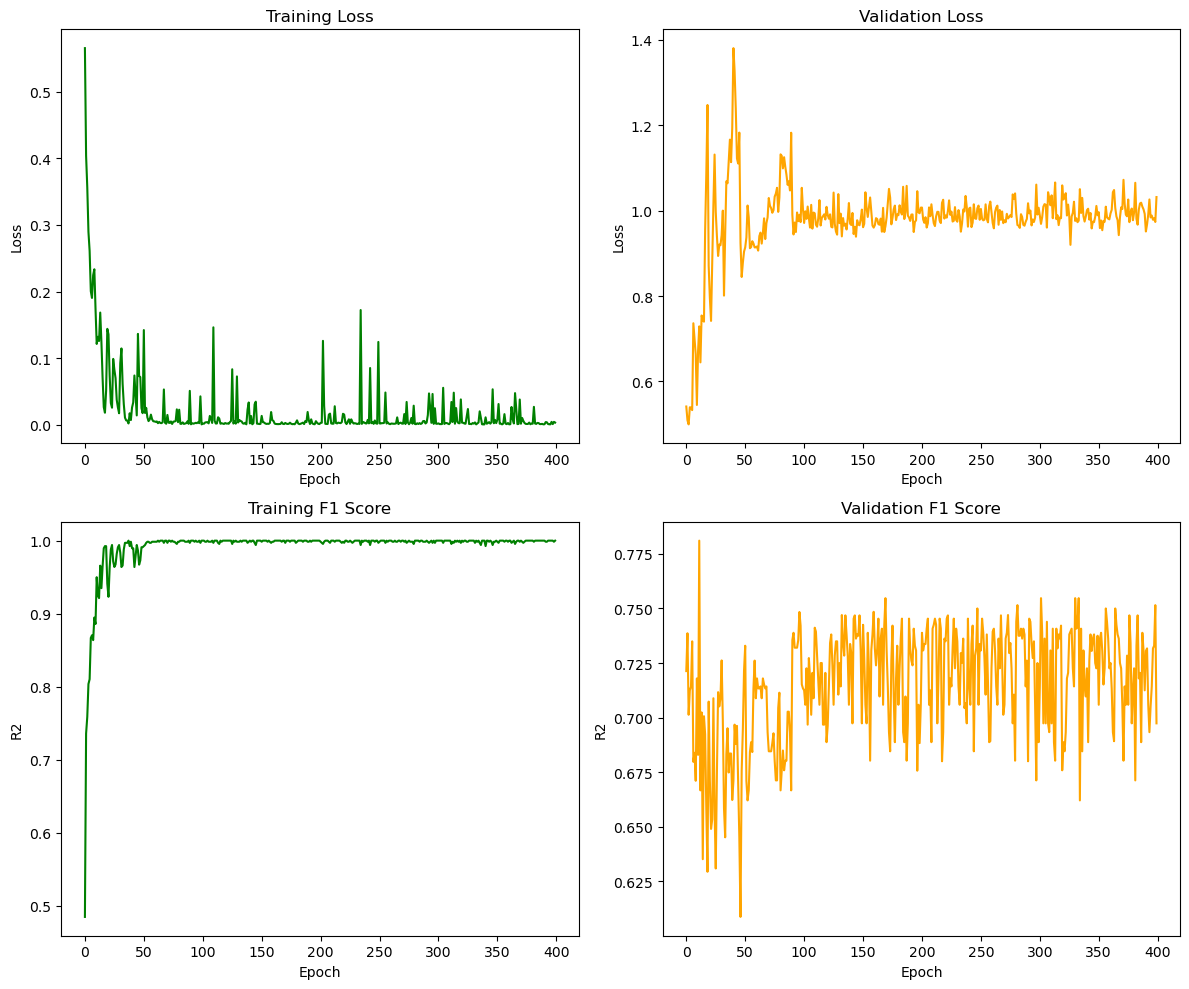

In [845]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_lossess, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_lossess, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(f1_train, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='R2')
ax[1, 0].set_title('Training F1 Score')

ax[1, 1].plot(f1_val, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='R2')
ax[1, 1].set_title('Validation F1 Score')
plt.tight_layout()

plt.show()

In [846]:
torch.save(best_model_state, 'best_model.pth')
print("Training complete. Best model saved as 'best_model.pth'")

Training complete. Best model saved as 'best_model.pth'


In [847]:
best_model_state = torch.load('best_model.pth', map_location=torch.device('cpu'))
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [848]:
y_pred_sex = model(X_val_sex_tensor)
y_pred_sex = torch.round(nn.Sigmoid()(y_pred_sex))
y_pred_sex = y_pred_sex.detach().numpy()
y_pred_sex = y_pred_sex.flatten()
y_pred_sex = y_pred_sex.astype(int)
y_pred_sex

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0])

In [849]:
submission_simulation = pd.read_csv('Submission_pred.csv')
submission_simulation['Sex_F'] = y_pred_sex
submission_simulation.to_csv('Submission_pred.csv', index=False)

### Submission

In [836]:
X_test_sex_tensor.shape

torch.Size([304, 200])

In [837]:
y_pred = model(X_test_sex_tensor)
y_pred
nn.Sigmoid()(y_pred)
y_pred = torch.round(nn.Sigmoid()(y_pred))
y_pred = y_pred.detach().numpy()
y_pred = y_pred.flatten()
y_pred = y_pred.astype(int)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [838]:
submission = pd.read_csv('./ThuyDuc_New/submission-ThuyDuc.csv')

In [839]:
submission['Sex_F'] = y_pred
submission.to_csv('./ThuyDuc_New/submission-ThuyDuc.csv', index=False)